In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

OUT_DIR = r'd:\Tseng\game_eeg\winrate_predict'

df_m = pd.read_csv(f'{OUT_DIR}\\master_parietal_190d.csv')
df_a = pd.read_csv(f'{OUT_DIR}\\amateur_parietal_190d.csv')
df_p = pd.read_csv(f'{OUT_DIR}\\prof_parietal_190d.csv')

META_COLS = ['SubjectID', 'Session', 'Epoch', 'Rate']
FEAT_COLS = [c for c in df_m.columns if c not in META_COLS]
SESSIONS  = ['ss01', 'ss02', 'ss03']

print('Master  sessions:', df_m['Session'].value_counts().to_dict())
print('Amateur sessions:', df_a['Session'].value_counts().to_dict())
print('Prof    sessions:', df_p['Session'].value_counts().to_dict())

Master  sessions: {'ss02': 625, 'ss03': 623, 'ss01': 578}
Amateur sessions: {'ss02': 796, 'ss01': 773, 'ss03': 771}
Prof    sessions: {'ss01': 240, 'ss03': 240, 'ss02': 239}


In [13]:
results = {}

for ss in SESSIONS:
    print(f'\n====== {ss} ======')

    tr   = df_m[df_m['Session'] == ss]
    te_a = df_a[df_a['Session'] == ss]
    te_p = df_p[df_p['Session'] == ss]

    X_tr = tr[FEAT_COLS].values
    y_tr = tr['Rate'].values
    print(f'  Master train: {len(X_tr)} trials  Rate={y_tr.min():.1f}~{y_tr.max():.1f}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=1.0)
    svr.fit(X_tr_s, y_tr)

    results[ss] = {}
    for name, te_df in [('amateur', te_a), ('prof', te_p)]:
        X_te   = te_df[FEAT_COLS].values
        y_te   = te_df['Rate'].values
        y_pred = svr.predict(scaler.transform(X_te))

        pr, pp = pearsonr(y_te, y_pred)
        sr, sp = spearmanr(y_te, y_pred)
        mae    = mean_absolute_error(y_te, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
        r2     = r2_score(y_te, y_pred)

        results[ss][name] = {
            'y_true': y_te, 'y_pred': y_pred,
            'pearson': pr, 'pearson_p': pp,
            'spearman': sr, 'spearman_p': sp,
            'mae': mae, 'rmse': rmse, 'r2': r2,
        }
        print(f'  [{name}] N={len(y_te)}  '
              f'Pearson r={pr:.4f}(p={pp:.4f})  '
              f'Spearman r={sr:.4f}(p={sp:.4f})  '
              f'RMSE={rmse:.2f}%')


====== ss01 ======
  Master train: 578 trials  Rate=7.5~77.0
  [amateur] N=773  Pearson r=0.0534(p=0.1377)  Spearman r=0.0477(p=0.1854)  RMSE=14.57%
  [prof] N=240  Pearson r=0.0380(p=0.5584)  Spearman r=0.0382(p=0.5560)  RMSE=13.01%

====== ss02 ======
  Master train: 625 trials  Rate=4.5~93.0
  [amateur] N=796  Pearson r=0.0164(p=0.6439)  Spearman r=0.0174(p=0.6240)  RMSE=22.09%
  [prof] N=239  Pearson r=-0.0012(p=0.9852)  Spearman r=0.0168(p=0.7965)  RMSE=20.04%

====== ss03 ======
  Master train: 623 trials  Rate=0.2~99.4
  [amateur] N=771  Pearson r=0.0081(p=0.8224)  Spearman r=0.0050(p=0.8900)  RMSE=35.22%
  [prof] N=240  Pearson r=0.0788(p=0.2237)  Spearman r=0.0883(p=0.1727)  RMSE=29.53%


In [14]:
print('=' * 70)
print(f'{"Session":<8} {"Group":<10} {"N":>5} {"Pearson r":>10} {"Spearman r":>11} {"RMSE":>8}')
print('-' * 70)
for ss in SESSIONS:
    for name in ['amateur', 'prof']:
        r = results[ss][name]
        sig_p = '*' if r['pearson_p'] < 0.05 else ' '
        sig_s = '*' if r['spearman_p'] < 0.05 else ' '
        print(f'{ss}  {name:<10} {len(r["y_true"]):>5} '
              f'{r["pearson"]:>9.4f}{sig_p} '
              f'{r["spearman"]:>10.4f}{sig_s} '
              f'{r["rmse"]:>7.2f}%')
print('=' * 70)
print('* p < 0.05')

Session  Group          N  Pearson r  Spearman r     RMSE
----------------------------------------------------------------------
ss01  amateur      773    0.0534      0.0477    14.57%
ss01  prof         240    0.0380      0.0382    13.01%
ss02  amateur      796    0.0164      0.0174    22.09%
ss02  prof         239   -0.0012      0.0168    20.04%
ss03  amateur      771    0.0081      0.0050    35.22%
ss03  prof         240    0.0788      0.0883    29.53%
* p < 0.05


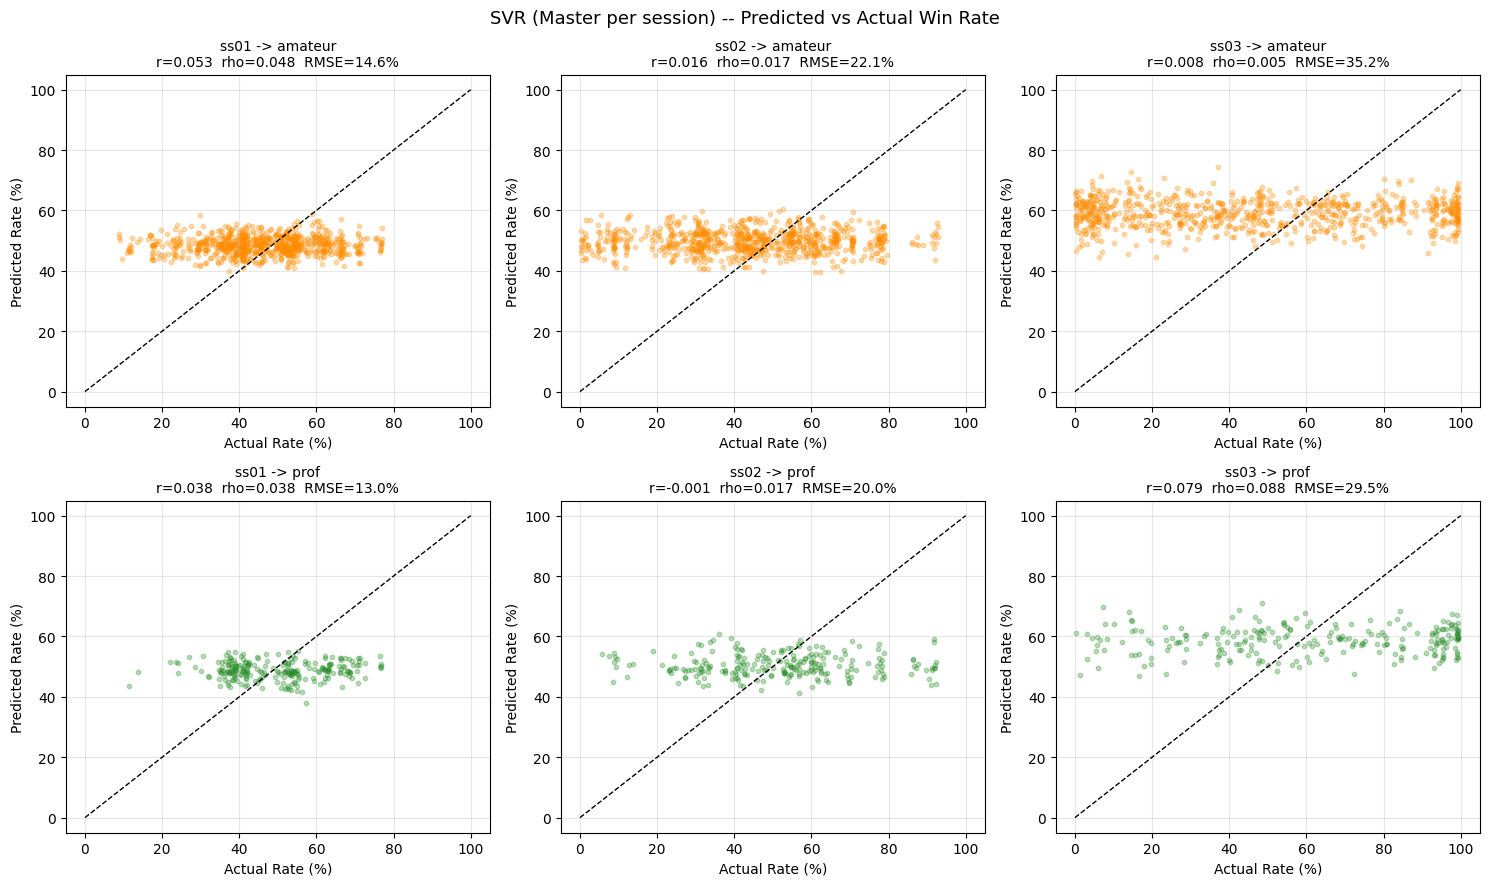

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
COLORS = {'amateur': 'darkorange', 'prof': 'forestgreen'}

for col, ss in enumerate(SESSIONS):
    for row, name in enumerate(['amateur', 'prof']):
        r = results[ss][name]
        ax = axes[row, col]
        ax.scatter(r['y_true'], r['y_pred'], alpha=0.3, s=10, color=COLORS[name])
        ax.plot([0, 100], [0, 100], 'k--', lw=1)
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.set_title(
            f'{ss} -> {name}\n'
            f'r={r["pearson"]:.3f}  rho={r["spearman"]:.3f}  RMSE={r["rmse"]:.1f}%',
            fontsize=10
        )
        ax.set_xlabel('Actual Rate (%)')
        ax.set_ylabel('Predicted Rate (%)')
        ax.grid(alpha=0.3)

plt.suptitle('SVR (Master per session) -- Predicted vs Actual Win Rate', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}\\svr_rate_per_session.png', dpi=150, bbox_inches='tight')
plt.show()